In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

In [14]:
data = pd.read_csv('dataset.csv')
data.head(10)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#symptom_columns = [col for col in data.columns if 'Symptom' in col]
symptom_columns = ['Symptom_1', 'Symptom_2', 'Symptom_3']
data = data[symptom_columns + ['Disease']]
data[symptom_columns] = data[symptom_columns].fillna('no_symptom')
data.head(10)

,Symptom_1,Symptom_2,Symptom_3,Disease
0,itching,skin_rash,nodal_skin_eruptions,Fungal infection
1,skin_rash,nodal_skin_eruptions,dischromic _patches,Fungal infection
2,itching,nodal_skin_eruptions,dischromic _patches,Fungal infection
3,itching,skin_rash,dischromic _patches,Fungal infection
4,itching,skin_rash,nodal_skin_eruptions,Fungal infection
5,skin_rash,nodal_skin_eruptions,dischromic _patches,Fungal infection
6,itching,nodal_skin_eruptions,dischromic _patches,Fungal infection
7,itching,skin_rash,dischromic _patches,Fungal infection
8,itching,skin_rash,nodal_skin_eruptions,Fungal infection
9,itching,skin_rash,nodal_skin_eruptions,Fungal infection


In [16]:
le = LabelEncoder()
data['Disease'] = le.fit_transform(data['Disease'])
data

,Symptom_1,Symptom_2,Symptom_3,Disease
0,itching,skin_rash,nodal_skin_eruptions,15
1,skin_rash,nodal_skin_eruptions,dischromic _patches,15
2,itching,nodal_skin_eruptions,dischromic _patches,15
3,itching,skin_rash,dischromic _patches,15
4,itching,skin_rash,nodal_skin_eruptions,15
...,...,...,...,...
4915,vomiting,headache,nausea,0
4916,skin_rash,pus_filled_pimples,blackheads,2
4917,burning_micturition,bladder_discomfort,foul_smell_of urine,38
4918,skin_rash,joint_pain,skin_peeling,35


In [17]:
X = data[symptom_columns]
y = data['Disease']

In [18]:
X_encoded = pd.get_dummies(X, columns=symptom_columns)
X_encoded

,Symptom_1_ acidity,Symptom_1_ back_pain,Symptom_1_ bladder_discomfort,Symptom_1_ breathlessness,Symptom_1_ burning_micturition,Symptom_1_ chest_pain,Symptom_1_ chills,Symptom_1_ constipation,Symptom_1_ continuous_sneezing,Symptom_1_ cough,...,Symptom_3_ stomach_pain,Symptom_3_ sweating,Symptom_3_ swelling_joints,Symptom_3_ swelling_of_stomach,Symptom_3_ ulcers_on_tongue,Symptom_3_ vomiting,Symptom_3_ watering_from_eyes,Symptom_3_ weakness_of_one_body_side,Symptom_3_ weight_loss,Symptom_3_ yellowish_skin
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4916,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4917,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4918,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [21]:
y_pred = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 95.22%


In [23]:
# joblib.dump(model, 'disease_prediction_model.pkl')
# joblib.dump(le, 'label_encoder.pkl')

Classification Metrics:
Accuracy Score: 0.95
Precision: 0.97
Recall: 0.95
F1-Score: 0.94


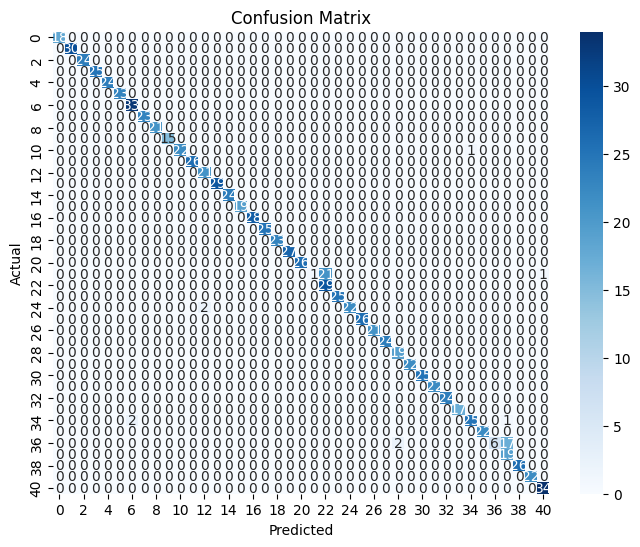

C:\Users\PMLS\AppData\Local\Temp\ipykernel_13972\1571158850.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


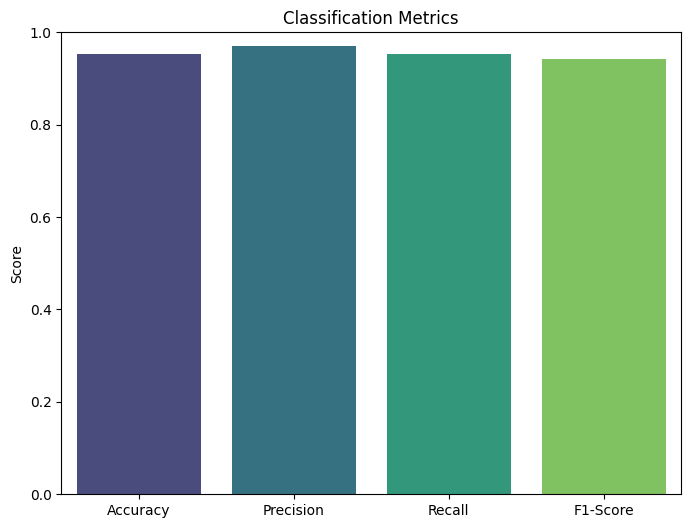

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
)
import seaborn as sns

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print Metrics
print("Classification Metrics:")
print(f"Accuracy Score: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Classification Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()
